# MIAMI → AnnData

The MIAMI dataset ([`cpg0006`](https://broadinstitute.github.io/cellpainting-gallery/)), two batches of compound plates.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*_normalized_feature_select_batch.csv.gz" \
  s3://cellpainting-gallery/cpg0006-miami/broad/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0006-miami/profiles").expanduser()

## Scoping to one batch

Feature selection ran per batch, so batches carry different feature sets and intersecting across them throws most features away.
This takes the batch with the most plates.

In [2]:
batches = sorted({p.parents[1].name for p in PROFILES.glob("*/*/*.csv.gz")})
BATCH = max(batches, key=lambda b: len(list((PROFILES / b).glob("*/*"))))
print(f"{len(batches)} batches, using {BATCH}")
files = sorted((PROFILES / BATCH).glob("*/*"))

2 batches, using 2021_08_23_Batch12


In [3]:
adata = cpio.read_profiles(
    files, index_columns=["batch", "Plate", "Well"], path_columns={"batch": 2}, on_column_mismatch="intersect"
)
adata

AnnData object with n_obs × n_vars = 1387 × 264
    obs: 'broad_sample', 'Plate', 'Well', 'Site_Count', 'Count_Cells', 'Count_CellsIncludingEdges', 'Count_Cytoplasm', 'Count_Nuclei', 'Count_NucleiIncludingEdges', 'Object_Count', 'batch'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


cpio.categorize(adata, present(["Plate", "plate_map_name", "pert_type", "control_type"]))
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Image_Granularity_10_BFHigh,image,granularity,brightfield_high,NaN,1
Image_Granularity_10_BFLow,image,granularity,brightfield_low,NaN,1
Image_Granularity_10_Brightfield,image,granularity,brightfield,NaN,1
Image_Granularity_11_BFHigh,image,granularity,brightfield_high,NaN,1
Image_Granularity_11_BFLow,image,granularity,brightfield_low,NaN,1
...,...,...,...,...,...
Nuclei_Texture_Correlation_Brightfield_5_03_256,nuclei,texture,brightfield,NaN,1
Nuclei_Texture_Correlation_DNA_10_03_256,nuclei,texture,dna,NaN,1
Nuclei_Texture_Correlation_DNA_5_02_256,nuclei,texture,dna,NaN,1


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["Plate"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

1,387 wells x 264 features
non-finite: 0 | max|x|: 400.8

Plate:
Plate
BR00126113    384
BR00126707    384
BR00126102    124
BR00126103    124
BR00126104    124
BR00126105    124


In [6]:
adata.write_h5ad(PROFILES.parent / "miami.h5ad")

## UMAP

The profiles are already normalized, so they enter PCA unscaled.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["Plate", "Site_Count"]))

,observed,baseline,ratio
covariate,,,
Plate,0.287,0.193,1.487
Site_Count,0.982,0.971,1.011


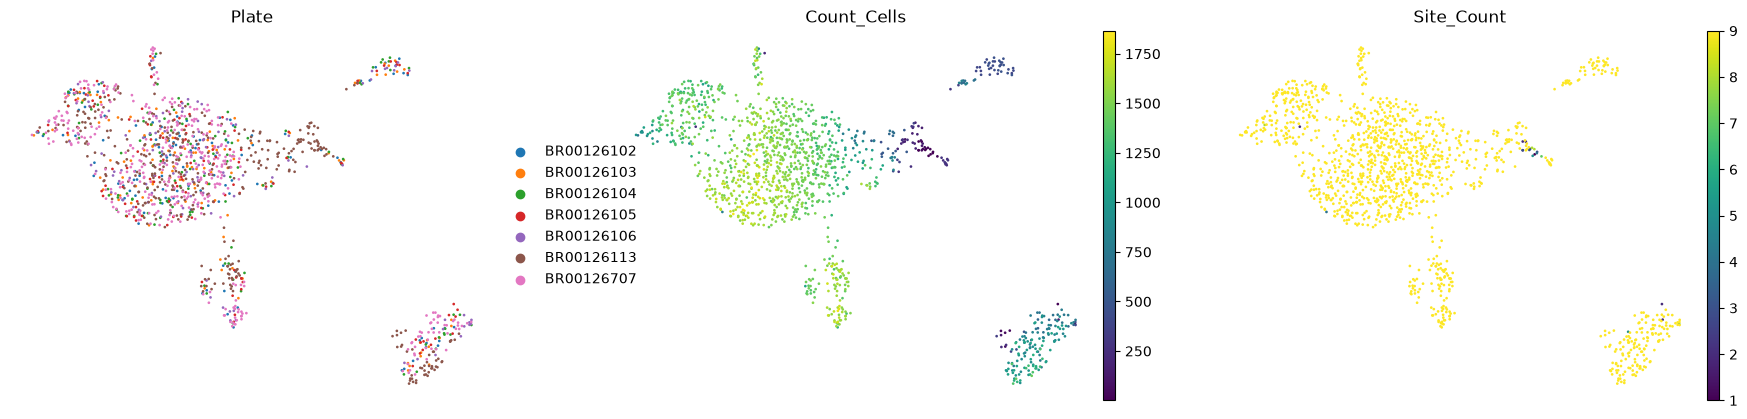

In [9]:
sc.pl.umap(adata, color=present(["Plate", "Count_Cells", "Site_Count"])[:3], ncols=3, frameon=False, size=15)